# Do Companies with Stronger Financial Fundamentals Generate Higher Stock Returns?

Ruba Abdelgalil

This project investigates whether firm financial fundamentals, including profitability, liquidity, leverage, and firm size, are associated with annual stock returns. Financial statement data and stock price data from the NYSE Kaggle dataset are merged and analyzed using ordinary least squares (OLS) regression in Python.

## Import Libraries

The analysis uses Python libraries for data manipulation, visualization, and statistical modeling.

In [ ]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Data Collection
The NYSE dataset is downloaded from Kaggle and loaded into Python.

In [ ]:
path = kagglehub.dataset_download("dgawlik/nyse")

print("Path:", path)

Using Colab cache for faster access to the 'nyse' dataset.
Path: /kaggle/input/nyse


In [ ]:
fundamentals = pd.read_csv(path + "/fundamentals.csv")
prices = pd.read_csv(path + "/prices.csv")

In [ ]:
print("Fundamentals:", fundamentals.shape)
print("Prices:", prices.shape)

Fundamentals: (1781, 79)
Prices: (851264, 7)


In [ ]:
fundamentals.head()

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


In [ ]:
prices.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


## Data Preparation

The stock price and financial statement data are prepared for analysis. Dates are converted into datetime format, annual stock returns are calculated, the datasets are merged by company and fiscal year, and observations with missing values are removed.

In [ ]:
prices["date"] = pd.to_datetime(
    prices["date"],
    format="mixed"
)

prices.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [ ]:
prices["Year"] = prices["date"].dt.year

prices[["date", "Year"]].head()

,date,Year
0,2016-01-05,2016
1,2016-01-06,2016
2,2016-01-07,2016
3,2016-01-08,2016
4,2016-01-11,2016


In [ ]:
year_end_prices = (
    prices
    .sort_values(["symbol", "date"])
    .groupby(["symbol", "Year"], as_index=False)
    .last()
)

year_end_prices.head()

,symbol,Year,date,open,close,low,high,volume
0,A,2010,2010-12-31,41.430000,41.430000,41.240000,41.699999,2050700.0
1,A,2011,2011-12-30,34.929999,34.929999,34.819999,35.509999,1930900.0
2,A,2012,2012-12-31,39.690000,40.940001,39.639999,40.970001,4707900.0
3,A,2013,2013-12-31,57.450001,57.189999,57.080001,57.549999,1316000.0
4,A,2014,2014-12-31,41.389999,40.939999,40.900002,41.790001,1421100.0


In [ ]:
year_end_prices["AnnualReturn"] = (
    year_end_prices
    .groupby("symbol")["close"]
    .pct_change()
)

year_end_prices.head(15)

,symbol,Year,date,open,close,low,high,volume,AnnualReturn
0,A,2010,2010-12-31,41.430000,41.430000,41.240000,41.699999,2050700.0,NaN
1,A,2011,2011-12-30,34.929999,34.929999,34.819999,35.509999,1930900.0,-0.156891
2,A,2012,2012-12-31,39.690000,40.940001,39.639999,40.970001,4707900.0,0.172058
3,A,2013,2013-12-31,57.450001,57.189999,57.080001,57.549999,1316000.0,0.396922
4,A,2014,2014-12-31,41.389999,40.939999,40.900002,41.790001,1421100.0,-0.284141
5,A,2015,2015-12-31,41.900002,41.810001,41.720001,42.349998,1449300.0,0.021251
6,A,2016,2016-12-30,45.759998,45.560001,45.380001,45.820000,1216100.0,0.089691
7,AAL,2010,2010-12-31,10.160000,10.010000,9.950000,10.190000,2191900.0,NaN
8,AAL,2011,2011-12-30,5.190000,5.070000,5.050000,5.230000,5496300.0,-0.493506
9,AAL,2012,2012-12-31,12.850000,13.500000,12.840000,13.680000,7005600.0,1.662722


In [ ]:
fundamentals[["Period Ending", "For Year"]].head()

,Period Ending,For Year
0,2012-12-31,2012.0
1,2013-12-31,2013.0
2,2014-12-31,2014.0
3,2015-12-31,2015.0
4,2012-12-29,2012.0


In [ ]:
merged = fundamentals.merge(
    year_end_prices,
    left_on=["Ticker Symbol", "For Year"],
    right_on=["symbol", "Year"],
    how="inner"
)

merged.head()

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Estimated Shares Outstanding,symbol,Year,date,open,close,low,high,volume,AnnualReturn
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,3.350000e+08,AAL,2012,2012-12-31,12.850000,13.500000,12.840000,13.680000,7005600.0,1.662722
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.630222e+08,AAL,2013,2013-12-31,24.740000,25.250000,24.629999,25.250000,7166600.0,0.870370
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,7.169154e+08,AAL,2014,2014-12-31,53.900002,53.630001,53.320000,54.639999,10626000.0,1.123960
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,6.681299e+08,AAL,2015,2015-12-31,42.540001,42.349998,41.830002,42.570000,6788900.0,-0.210330
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,7.328355e+07,AAP,2012,2012-12-31,71.389999,72.349998,71.300003,72.550003,454500.0,0.039064


In [ ]:
 merged.shape

(1590, 88)

In [ ]:
analysis = merged[
    [
        "AnnualReturn",
        "After Tax ROE",
        "Profit Margin",
        "Current Ratio",
        "Long-Term Debt",
        "Gross Margin",
        "Total Assets"
    ]
]

In [ ]:
analysis.isnull().sum()

,0
AnnualReturn,21
After Tax ROE,0
Profit Margin,0
Current Ratio,263
Long-Term Debt,0
Gross Margin,0
Total Assets,0


In [ ]:
analysis = analysis.dropna()

analysis.shape

(1309, 7)

## Exploratory Data Analysis

Before estimating the regression model, descriptive statistics and visualizations are used to summarize the data and examine relationships among the variables. This step helps identify potential patterns, assess correlations, and evaluate whether the variables are suitable for regression analysis.

In [ ]:
analysis.describe().round(2)

,AnnualReturn,After Tax ROE,Profit Margin,Current Ratio,Long-Term Debt,Gross Margin,Total Assets
count,1309.00,1309.00,1309.00,1309.00,1.309000e+03,1309.00,1.309000e+03
mean,0.14,47.01,12.77,183.95,6.621040e+09,46.58,2.673441e+10
std,0.33,248.94,17.00,123.55,1.106371e+10,22.09,4.357653e+10
min,-0.90,0.00,0.00,17.00,0.000000e+00,2.00,1.043325e+09
25%,-0.04,11.00,6.00,109.00,1.150100e+09,31.00,6.141462e+09
50%,0.13,18.00,10.00,149.00,3.383581e+09,42.00,1.303300e+10
75%,0.30,28.00,15.00,223.00,7.776833e+09,61.00,3.120900e+10
max,2.98,5789.00,369.00,1125.00,1.191710e+11,100.00,4.026720e+11


In [ ]:
correlation = analysis.corr()

correlation.round(2)

,AnnualReturn,After Tax ROE,Profit Margin,Current Ratio,Long-Term Debt,Gross Margin,Total Assets
AnnualReturn,1.00,-0.02,-0.08,0.08,-0.08,-0.01,-0.07
After Tax ROE,-0.02,1.00,0.10,-0.02,-0.01,0.03,-0.04
Profit Margin,-0.08,0.10,1.00,0.14,-0.02,0.33,-0.01
Current Ratio,0.08,-0.02,0.14,1.00,-0.13,0.13,-0.14
Long-Term Debt,-0.08,-0.01,-0.02,-0.13,1.00,-0.04,0.80
Gross Margin,-0.01,0.03,0.33,0.13,-0.04,1.00,-0.06
Total Assets,-0.07,-0.04,-0.01,-0.14,0.80,-0.06,1.00


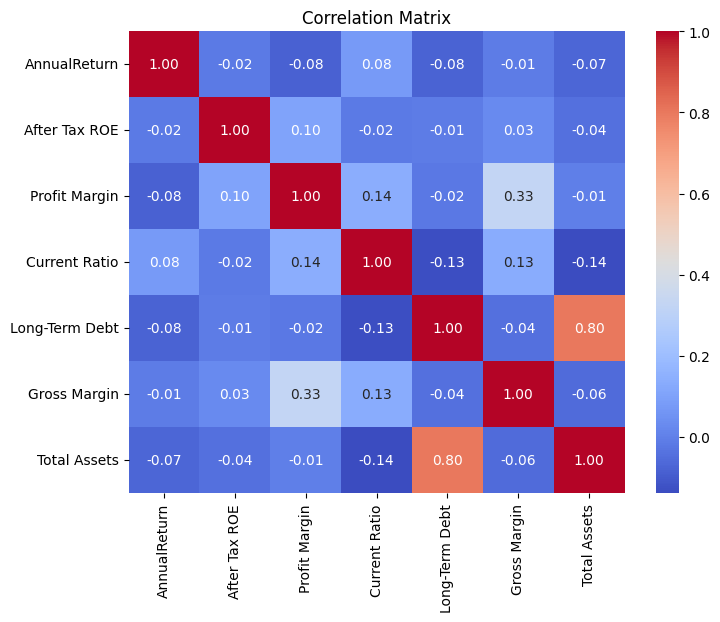

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

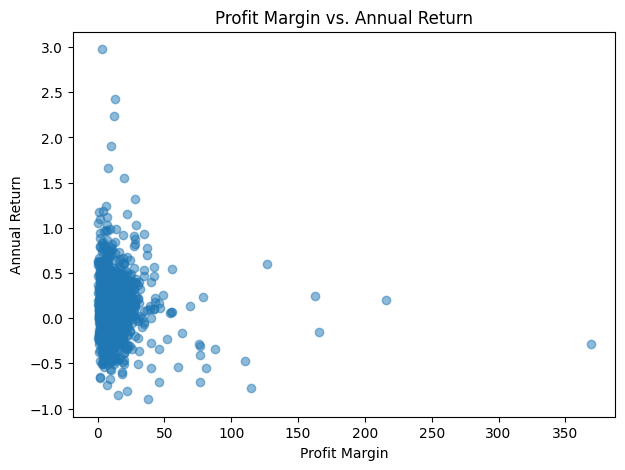

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    analysis["Profit Margin"],
    analysis["AnnualReturn"],
    alpha=0.5
)

plt.xlabel("Profit Margin")
plt.ylabel("Annual Return")
plt.title("Profit Margin vs. Annual Return")

plt.show()

## Regression Model

Annual stock returns are modeled as a function of firm probability, liquidity, leverage, and size using ordinary least squares (OLS) regression. The independent variables include After Tax ROE, Profit Margin, Current Ratio, Long-Term Debt, Gross Margin, and Total Assets.

In [ ]:
X = analysis[
    [
        "After Tax ROE",
        "Profit Margin",
        "Current Ratio",
        "Long-Term Debt",
        "Gross Margin",
        "Total Assets"
    ]
]

y = analysis["AnnualReturn"]

In [ ]:
X = sm.add_constant(X)

In [ ]:
model = sm.OLS(y, X)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AnnualReturn   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.485
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           0.000167
Time:                        15:24:15   Log-Likelihood:                -380.38
No. Observations:                1309   AIC:                             774.8
Df Residuals:                    1302   BIC:                             811.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2088      0.276      0.

### Alternative Model: Log-Transformed Firm Size

Because Total Assets is highly skewed across firms, the natural logarithm of Total Assets is used as an alternative measure of firm size. Log transformation reduces the influence of extreme values and is standard practice in empirical finance.

In [ ]:
analysis["LogTotalAssets"] = np.log(analysis["Total Assets"])

analysis[["Total Assets", "LogTotalAssets"]].head()

,Total Assets,LogTotalAssets
0,2.351000e+10,23.880692
1,4.227800e+10,24.467533
2,4.322500e+10,24.489685
3,4.841500e+10,24.603076
4,4.613814e+09,22.252321


In [ ]:
X = analysis[
    [
        "After Tax ROE",
        "Profit Margin",
        "Current Ratio",
        "Long-Term Debt",
        "Gross Margin",
        "LogTotalAssets"
    ]
]

X = sm.add_constant(X)

y = analysis["AnnualReturn"]

In [ ]:
model = sm.OLS(y, X)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AnnualReturn   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.485
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           0.000167
Time:                        15:22:43   Log-Likelihood:                -380.38
No. Observations:                1309   AIC:                             774.8
Df Residuals:                    1302   BIC:                             811.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2088      0.276      0.

### Model Diagnostics

The following diagnostics evaluate multicollinearity among the explanatory variables and estimate heteroskedasticity-robust standard errors.

In [ ]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Variable,VIF
0,const,949.511857
1,After Tax ROE,1.028693
2,Profit Margin,1.152762
3,Current Ratio,1.130685
4,Long-Term Debt,1.894356
5,Gross Margin,1.142426
6,LogTotalAssets,2.066356


In [ ]:
robust_results = model.fit(cov_type="HC3")

print(robust_results.summary())

                            OLS Regression Results                            
Dep. Variable:           AnnualReturn   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     3.024
Date:                Sat, 04 Jul 2026   Prob (F-statistic):             0.0101
Time:                        15:22:43   Log-Likelihood:                -380.38
No. Observations:                1309   AIC:                             774.8
Df Residuals:                    1302   BIC:                             811.0
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2088      0.250      0.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '


## Conclusion

This analysis examined whether firms with stronger financial fundamentals generated higher annual stock returns. Ordinary least squares regression revealed that Profit Margin and Current Ratio were statistically significant predictors of annual returns, while Return on Equity, Gross Margin, Long-Term Debt, and firm size were not statistically significant after controlling for the other variables.

Overall, the model explained approximately 2% of the variation in annual stock returns (R² = 0.020), suggesting that financial statement variables alone have limited power in explaining year-to-year stock performance. These findings are consistent with the view that stock returns are influenced by many additional factors, including macroeconomic conditions, investor expectations, and market sentiment.